# 온라인 쇼핑객 Revenue 예측 - Random Forest

이 노트북은 `docs/DataPreProcessing.md`의 Tree/RF 전처리 기준을 사용해
Random Forest 모델 설계 및 성능 평가 단계를 재현한다.

핵심 결정:
- `PageValues`는 예측 시점 이후 집계될 수 있는 누수 변수로 판단해 메인 모델에서 제외
- Tree/RF 계열용 파생 변수 4개 추가
- `Month`, `VisitorType` One-Hot 인코딩
- 클래스 불균형은 `class_weight='balanced'`로 처리


In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.tree import export_text, plot_tree

repo_root = Path.cwd()
if not (repo_root / "data").exists():
    repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))

from models.random_forest.random_forest_pipeline import (
    build_tree_preprocessed_data,
    load_online_shoppers_data,
    run_random_forest_experiment,
)

plt.rcParams["figure.figsize"] = (8, 4.5)


## 1. 전처리 상태 확인

원본 CSV는 12,330행 18열이며, `Revenue`가 타깃이다.
전처리 노트북은 모델 학습용 파일을 저장하지 않고 변수 산출까지만 수행하므로,
아래 셀에서 같은 전처리 규칙을 함수로 재현한다.


In [2]:
df = load_online_shoppers_data()
data = build_tree_preprocessed_data(df)

print(f"원본 데이터: {df.shape}")
print(f"학습 데이터: {data.X_train.shape}, 양성 비율: {data.y_train.mean():.4f}")
print(f"테스트 데이터: {data.X_test.shape}, 양성 비율: {data.y_test.mean():.4f}")
print(f"PageValues 포함 여부: {'PageValues' in data.X_train.columns}")
print(f"피처 수: {len(data.X_train.columns)}")
data.X_train.head()


원본 데이터: (12330, 18)
학습 데이터: (9864, 31), 양성 비율: 0.1547
테스트 데이터: (2466, 31), 양성 비율: 0.1549
PageValues 포함 여부: False
피처 수: 31


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,OperatingSystems,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
4263,8,732.25,0,0.0,34,1345.755952,0.005128,0.013342,0.8,3,...,0,0,0,1,0,0,0,0,0,1
5905,0,0.00,0,0.0,4,157.200000,0.040000,0.100000,0.0,1,...,0,0,0,0,0,1,0,0,0,1
9434,0,0.00,0,0.0,4,42.000000,0.000000,0.050000,0.0,2,...,0,0,0,0,0,0,0,0,0,1
3505,2,338.00,0,0.0,17,1205.566667,0.012500,0.037500,0.8,3,...,0,0,0,1,0,0,0,0,0,1
2067,0,0.00,0,0.0,32,827.646212,0.000000,0.000587,0.0,2,...,0,0,1,0,0,0,0,0,0,1


## 2. 모델 설계 및 적용

기본 Random Forest와 F1 기준 GridSearchCV 튜닝 모델을 비교한다.
구매자가 15.5% 정도인 불균형 분류이므로 Accuracy만 보지 않고
Precision, Recall, F1, ROC-AUC, PR-AUC를 함께 평가한다.

`docs/ALGORITHMS.md` 기준으로 Random Forest는 분류 허용 기법에 해당한다.
이번 문제는 `Revenue=True/False`를 맞히는 이진 분류 문제이므로 Random Forest를 적용하고,
하이퍼파라미터 튜닝으로 성능을 개선한다.


In [3]:
result = run_random_forest_experiment()

print("최적 파라미터:")
print(result.best_params)

result.metrics.round(4)


최적 파라미터:
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 300}


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest default,0.8431,0.4603,0.0759,0.1303,0.7616,0.3479
1,Random Forest tuned,0.6894,0.2890,0.6885,0.4071,0.7571,0.3489


## 3. 성능 평가

튜닝 모델의 혼동 행렬을 확인한다.
`actual_1`은 실제 구매 세션이며, `pred_1`은 구매로 예측한 세션이다.


In [4]:
result.confusion


,pred_0,pred_1
actual_0,1437,647
actual_1,119,263


### 3-1. 혼동 행렬 시각화

Random Forest가 구매/미구매를 어떻게 분류했는지 셀 안에서 바로 확인한다.


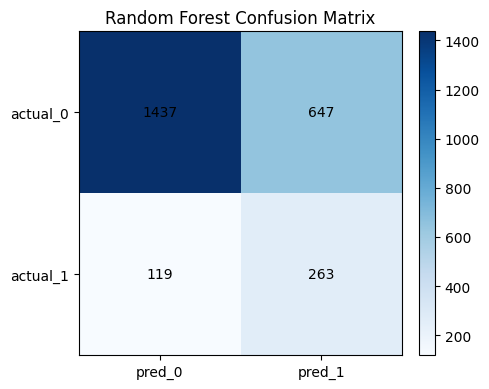

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
matrix = result.confusion.to_numpy()
im = ax.imshow(matrix, cmap="Blues")
ax.set_xticks(range(len(result.confusion.columns)), result.confusion.columns)
ax.set_yticks(range(len(result.confusion.index)), result.confusion.index)
for row in range(matrix.shape[0]):
    for col in range(matrix.shape[1]):
        ax.text(col, row, str(matrix[row, col]), ha="center", va="center")
ax.set_title("Random Forest Confusion Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 4. 결과 분석 및 해석

Random Forest는 여러 결정나무를 학습해 예측을 평균/투표하므로,
단일 트리보다 과적합에 강하고 변수 중요도 해석이 가능하다.
아래 표는 튜닝 모델에서 구매 전환 예측에 가장 크게 기여한 변수다.


In [6]:
result.feature_importance.round(4)


,feature,importance
7,ExitRates,0.1818
5,ProductRelated_Duration,0.1033
6,BounceRates,0.0901
15,total_duration,0.0888
16,avg_time_per_product,0.0700
4,ProductRelated,0.0608
14,total_pages,0.0604
1,Administrative_Duration,0.0470
25,Month_Nov,0.0426
0,Administrative,0.0423


### 4-1. 변수 중요도 시각화


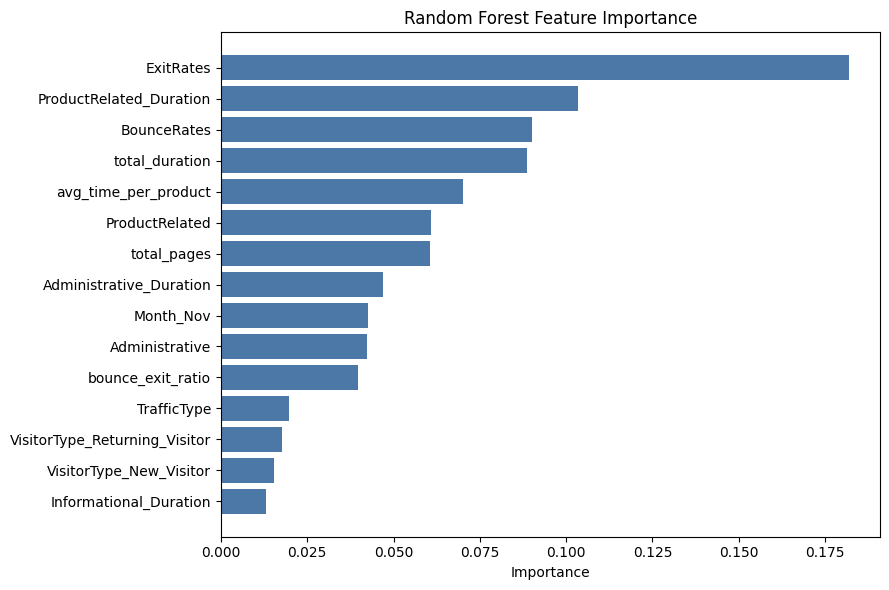

In [7]:
importance = result.feature_importance.sort_values("importance")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance["feature"], importance["importance"], color="#4c78a8")
ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


### 4-2. ROC / PR 곡선

불균형 데이터에서는 ROC-AUC와 함께 PR-AUC도 확인한다.


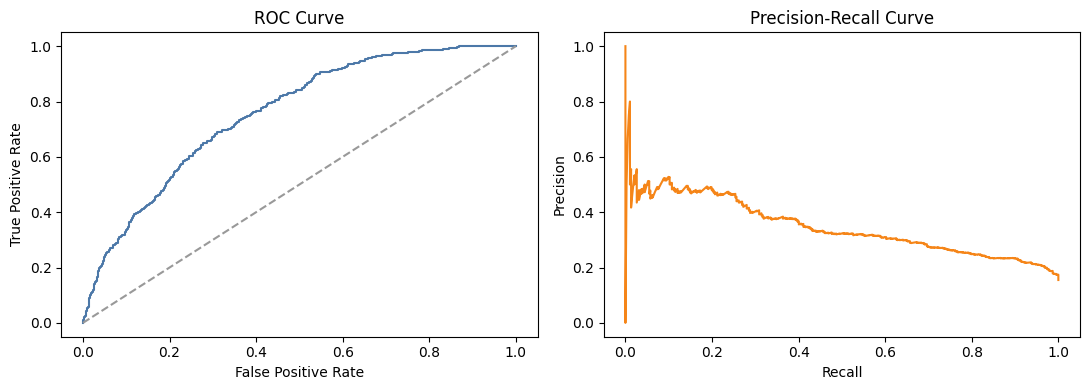

In [8]:
fpr, tpr, _ = roc_curve(result.y_test, result.y_prob)
precision, recall, _ = precision_recall_curve(result.y_test, result.y_prob)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, color="#4c78a8")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#999999")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")

axes[1].plot(recall, precision, color="#f58518")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
plt.tight_layout()
plt.show()


## 5. 예측 점수 구간별 실제 구매율

예측 확률을 10개 구간으로 나눴을 때, 상위 구간에서 실제 구매율도 높아지는지 확인한다.
이 표는 발표에서 "모델 점수가 실제 구매 가능성과 연결된다"는 근거로 사용한다.


In [9]:
result.decile_lift.round(4)


,score_decile,count,mean_predicted_proba,actual_purchase_rate,actual_buyers,lift_vs_baseline
0,1,247,0.0199,0.0000,0,0.0000
1,2,247,0.1012,0.0324,8,0.2091
2,3,246,0.1959,0.0407,10,0.2624
3,4,247,0.2749,0.0810,20,0.5227
4,5,246,0.3585,0.1504,37,0.9709
5,6,247,0.4414,0.1538,38,0.9932
6,7,246,0.5121,0.1626,40,1.0497
7,8,247,0.5735,0.2591,64,1.6727
8,9,246,0.6351,0.2480,61,1.6008
9,10,247,0.7361,0.4211,104,2.7181


### 5-1. 예측 점수 구간별 실제 구매율 시각화


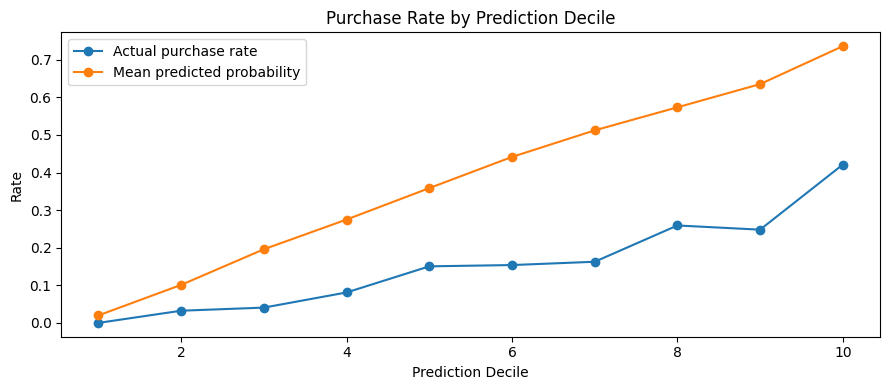

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    result.decile_lift["score_decile"],
    result.decile_lift["actual_purchase_rate"],
    marker="o",
    label="Actual purchase rate",
)
ax.plot(
    result.decile_lift["score_decile"],
    result.decile_lift["mean_predicted_proba"],
    marker="o",
    label="Mean predicted probability",
)
ax.set_title("Purchase Rate by Prediction Decile")
ax.set_xlabel("Prediction Decile")
ax.set_ylabel("Rate")
ax.legend()
plt.tight_layout()
plt.show()


## 6. 예측 상위 10%와 하위 10% 차이

상위 10%와 하위 10%의 평균 행동 지표 차이를 비교한다.
차이가 큰 변수는 Random Forest가 구매 가능성 높은 세션을 어떤 행동 패턴으로 구분했는지 설명하는 데 쓸 수 있다.


In [11]:
result.top_bottom_profile.round(4)


,feature,top_mean,bottom_mean,difference,abs_difference
15,total_duration,3492.9867,32.5513,3460.4354,3460.4354
5,ProductRelated_Duration,3246.2757,32.5513,3213.7244,3213.7244
1,Administrative_Duration,174.3540,0.0000,174.3540,174.3540
14,total_pages,88.3279,3.0567,85.2713,85.2713
4,ProductRelated,82.6397,3.0283,79.6113,79.6113
3,Informational_Duration,72.3570,0.0000,72.3570,72.3570
16,avg_time_per_product,42.5152,6.5551,35.9601,35.9601
0,Administrative,4.5830,0.0243,4.5587,4.5587
2,Informational,1.1053,0.0040,1.1012,1.1012
25,Month_Nov,0.7490,0.0972,0.6518,0.6518


### 6-1. 상위/하위 그룹 차이 시각화


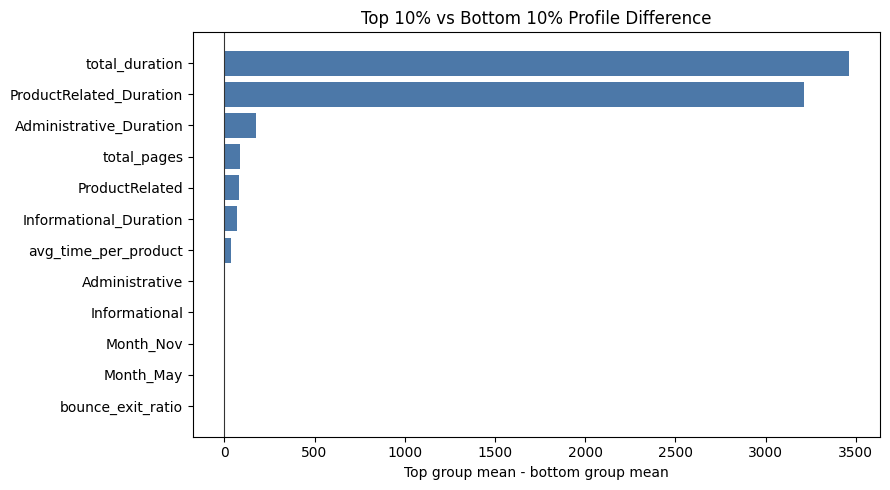

In [12]:
profile = result.top_bottom_profile.sort_values("difference")
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#e45756" if value < 0 else "#4c78a8" for value in profile["difference"]]
ax.barh(profile["feature"], profile["difference"], color=colors)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_title("Top 10% vs Bottom 10% Profile Difference")
ax.set_xlabel("Top group mean - bottom group mean")
plt.tight_layout()
plt.show()


## 7. Random Forest 대표 트리 시각화

Random Forest는 수백 개의 Decision Tree를 합친 앙상블이므로 모든 트리를 한 번에 보면 해석이 어렵다.
대신 그중 하나의 트리를 대표 예시로 뽑고, 깊이를 3으로 제한해 어떤 조건 분기가 일어나는지 확인한다.


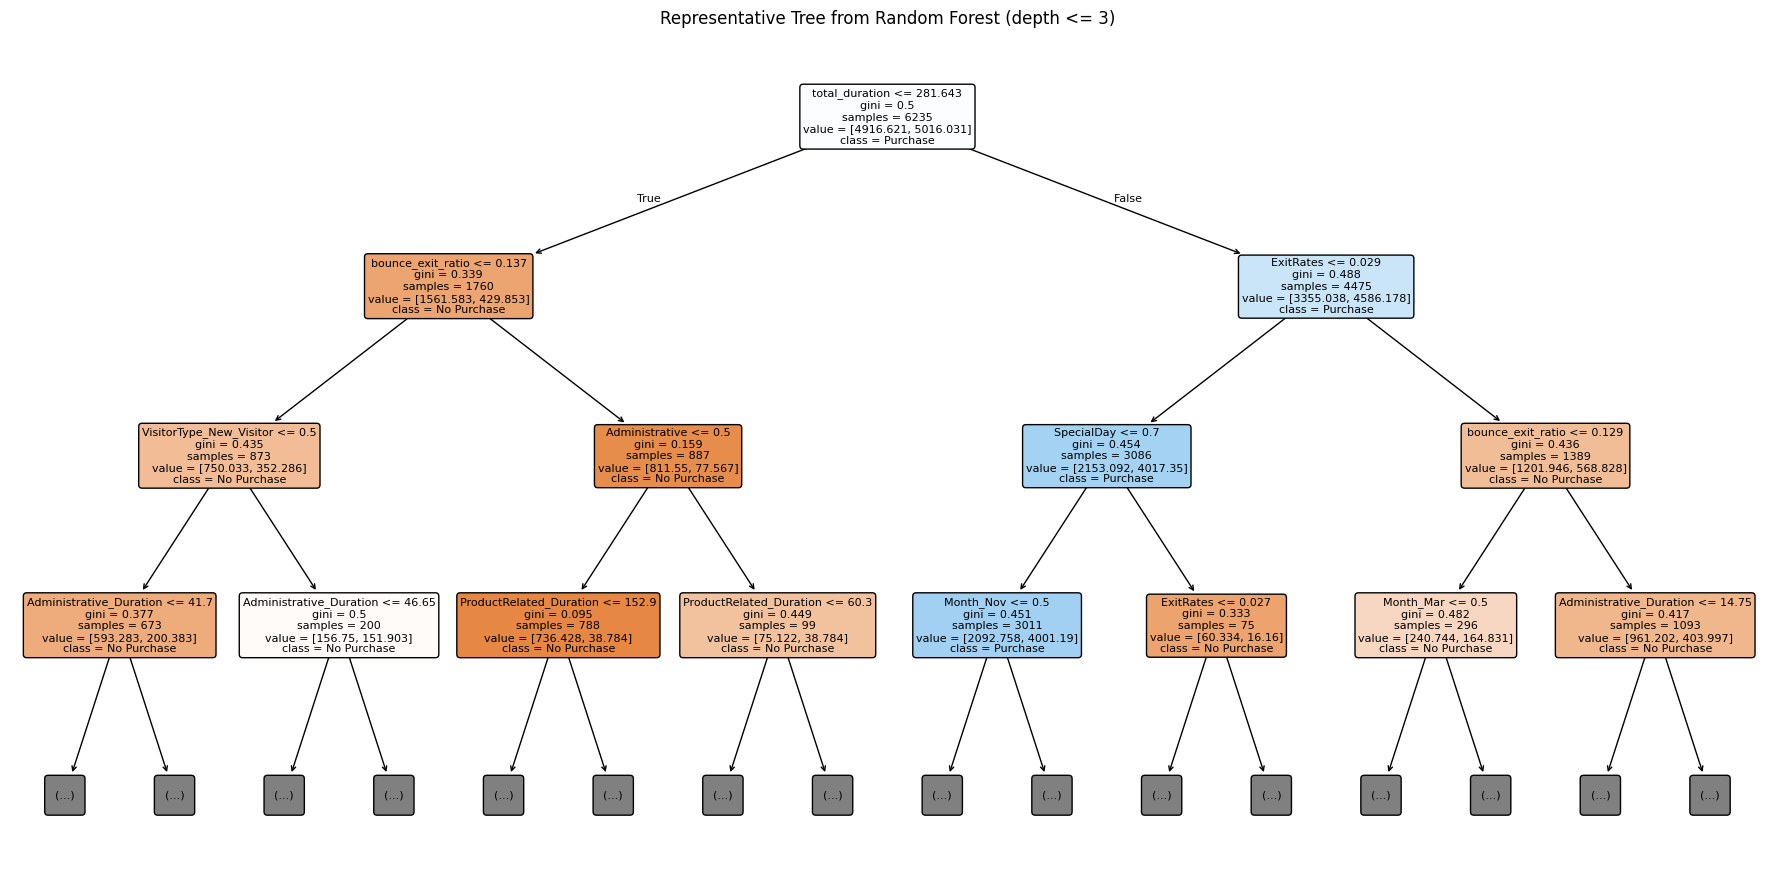

In [13]:
fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(
    result.model.estimators_[0],
    feature_names=result.feature_names,
    class_names=["No Purchase", "Purchase"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
ax.set_title("Representative Tree from Random Forest (depth <= 3)")
plt.tight_layout()
plt.show()


### 7-1. 대표 트리 규칙 텍스트

위 그림과 같은 대표 트리를 텍스트 규칙으로도 확인한다.


In [14]:
print(
    export_text(
        result.model.estimators_[0],
        feature_names=result.feature_names,
        max_depth=3,
    )
)


|--- total_duration <= 281.64
|   |--- bounce_exit_ratio <= 0.14
|   |   |--- VisitorType_New_Visitor <= 0.50
|   |   |   |--- Administrative_Duration <= 41.70
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Administrative_Duration >  41.70
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- VisitorType_New_Visitor >  0.50
|   |   |   |--- Administrative_Duration <= 46.65
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Administrative_Duration >  46.65
|   |   |   |   |--- truncated branch of depth 4
|   |--- bounce_exit_ratio >  0.14
|   |   |--- Administrative <= 0.50
|   |   |   |--- ProductRelated_Duration <= 152.90
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- ProductRelated_Duration >  152.90
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- Administrative >  0.50
|   |   |   |--- ProductRelated_Duration <= 60.30
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- ProductRelated_Duration > 

## 8. 산출물 저장 위치

전처리된 모델 입력 데이터는 `models/random_forest/csv/`에 저장된다.

- `csv/X_train.csv`
- `csv/X_test.csv`
- `csv/y_train.csv`
- `csv/y_test.csv`

모델 실행 결과는 `models/random_forest/outputs/`에 저장된다.

- `random_forest_metrics.csv`
- `random_forest_confusion_matrix.csv`
- `random_forest_feature_importance.csv`
- `random_forest_decile_lift.csv`
- `random_forest_top_bottom_profile.csv`
- `random_forest_summary.md`
